# Random Forest - Adult Income

Este notebook replica a estrutura de validação cruzada do `rec_validacao_cruzada.ipynb`, mas troca o Gaussian Naive Bayes por `RandomForestClassifier`.

O dataset tratado foi salvo em `adult_tratado_random_forest.csv` para evitar repetir o download e a limpeza em toda execução.

## Pré-processamento usado

Mantido do notebook original:

- padronização do alvo `income`;
- substituição de `?` por ausente;
- remoção de linhas com ausentes, duplicadas e registros conflitantes com as mesmas features e alvos diferentes;
- remoção de `fnlwgt`;
- agrupamento de `education`, `marital-status` e `native-country`;
- remoção de `educational-num` por redundância com `education`;
- codificação binária de `gender`;
- criação de `capital-balance = capital-gain - capital-loss`.

Removido por não ser necessário ou não ser a melhor escolha para Random Forest:

- discretização de `age` e `hours-per-week`: árvores já aprendem pontos de corte;
- `StandardScaler`: árvores são invariantes a escala;
- transformação logarítmica e clipping de outliers: árvores dependem da ordenação dos valores e são menos sensíveis a assimetria e extremos;
- PCA: tende a reduzir interpretabilidade e não é requisito para Random Forest;
- `SelectKBest`: a floresta já seleciona variáveis nos splits e o parâmetro `max_features` controla o subconjunto de variáveis candidatas por split.

As variáveis categóricas são codificadas com `OneHotEncoder`, porque `OrdinalEncoder` imporia uma ordem artificial em categorias nominais como `occupation`, `workclass` e `race`.

In [26]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, make_scorer, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42
RF_N_JOBS = -1
DATA_PATH = Path("adult_tratado_random_forest.csv")

## Carregamento do dataset tratado

In [27]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
display(df.head())
print()
print("Distribuição do alvo:")
display(df["income"].value_counts().rename(index={0: "<=50K", 1: ">50K"}).to_frame("count"))

Shape: (45165, 12)


,age,workclass,education,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,capital-balance,income
0,25,Private,dropout,NotMarried,Machine-op-inspct,Own-child,Black,1,40,United-States,0,0
1,38,Private,HighGrad,Married,Farming-fishing,Husband,White,1,50,United-States,0,0
2,28,Local-gov,CommunityCollege,Married,Protective-serv,Husband,White,1,40,United-States,0,1
3,44,Private,CommunityCollege,Married,Machine-op-inspct,Husband,Black,1,40,United-States,7688,1
4,34,Private,dropout,NotMarried,Other-service,Not-in-family,White,1,30,United-States,0,0



Distribuição do alvo:


,count
income,
<=50K,33968
>50K,11197


In [28]:
X = df.drop(columns=["income"])
y = df["income"].astype(int)

categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

raw_n_features = X.shape[1]

print(f"Número de features antes do OHE: {raw_n_features}")
print(f"Categóricas: {categorical_cols}")
print(f"Numéricas: {numeric_cols}")

Número de features antes do OHE: 11
Categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
Numéricas: ['age', 'gender', 'hours-per-week', 'capital-balance']


## Pipeline Random Forest

`mtry` no contexto de Random Forest corresponde ao `max_features` do `sklearn`. `ntree` corresponde a `n_estimators`.

O `OneHotEncoder` é usado apenas nas variáveis categóricas. O chute inicial de `mtry` usa a raiz quadrada do número de features depois do one-hot encoding, porque é nesse espaço transformado que o `RandomForestClassifier` escolhe os candidatos de split.

O desbalanceamento é tratado sempre com `class_weight="balanced"`, conforme decisão da análise. O grid calibra `max_features`, `n_estimators` e `min_samples_leaf`; folhas com pelo menos 2 exemplos podem reduzir sobreajuste em árvores muito profundas.

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_cols,
        ),
        ("numeric", "passthrough", numeric_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# Ajuste somente para dimensionar o grid de max_features. O pipeline abaixo refaz o fit
# do preprocessor dentro de cada fold da validação cruzada.
preprocessor.fit(X)
encoded_feature_names = preprocessor.get_feature_names_out()
n_model_features = len(encoded_feature_names)
sqrt_mtry = max(1, int(math.sqrt(n_model_features)))

rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=RF_N_JOBS,
    bootstrap=True,
    class_weight="balanced",
)

pipe_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("rf", rf),
    ]
)

max_features_grid = [value for value in [9, 11, 15, n_model_features] if value <= n_model_features]
max_features_grid = list(dict.fromkeys(max_features_grid))

param_grid = {
    "rf__max_features": max_features_grid,
    "rf__n_estimators": [100, 200, 300, 500],
    "rf__min_samples_leaf": [1, 2],
}

print(f"Features depois do OHE: {n_model_features}")
print(f"Chute inicial para mtry/max_features floor(sqrt(p_ohe)): {sqrt_mtry}")
print(f"Grid de max_features: {max_features_grid}")
print(f"Combinações no grid: {len(list(ParameterGrid(param_grid)))}")
print(json.dumps(param_grid, indent=2, default=str))

Features depois do OHE: 50
Chute inicial para mtry/max_features floor(sqrt(p_ohe)): 7
Grid de max_features: [9, 11, 15, 50]
Combinações no grid: 32
{
  "rf__max_features": [
    9,
    11,
    15,
    50
  ],
  "rf__n_estimators": [
    100,
    200,
    300,
    500
  ],
  "rf__min_samples_leaf": [
    1,
    2
  ]
}


## Validação cruzada aninhada

A estrutura segue o notebook anterior: `GridSearchCV` no loop interno otimizando F1 e `cross_validate` no loop externo reportando acurácia, F1, recall e precisão.

A tabela de folds mostra só o melhor conjunto escolhido dentro de cada fold externo. Para verificar que todas as combinações foram testadas, o notebook também monta `all_inner_results`, com o `cv_results_` completo de cada `GridSearchCV` interno.

O grid mantém `max_features` em 9, 11, 15 e todas as features, `n_estimators` em 100, 200, 300 e 500, `min_samples_leaf` em 1 e 2, e `class_weight="balanced"` fixo no classificador.

In [30]:
inner_splits = 3
outer_splits = 3
param_grid_run = param_grid

scoring_metrics = {
    "accuracy": make_scorer(accuracy_score),
    "f1": make_scorer(f1_score),
    "recall": make_scorer(recall_score),
    "precision": make_scorer(precision_score),
}

inner_cv = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)
outer_cv = StratifiedKFold(n_splits=outer_splits, shuffle=True, random_state=RANDOM_STATE)

search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_run,
    cv=inner_cv,
    scoring="f1",
    refit=True,
    n_jobs=1,
    verbose=1,
    error_score="raise",
)

nested_scores_rf = cross_validate(
    estimator=search_rf,
    X=X,
    y=y,
    cv=outer_cv,
    scoring=scoring_metrics,
    return_estimator=True,
    n_jobs=1,
    error_score="raise",
)

print("--- Random Forest com validação cruzada aninhada ---")
for metric_name, scores in nested_scores_rf.items():
    if metric_name.startswith("test_"):
        label = metric_name.replace("test_", "").capitalize()
        print(f"{label}: média = {scores.mean():.4f}, desvio padrão = {scores.std():.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Fitting 3 folds for each of 32 candidates, totalling 96 fits
Fitting 3 folds for each of 32 candidates, totalling 96 fits
--- Random Forest com validação cruzada aninhada ---
Accuracy: média = 0.8375, desvio padrão = 0.0043
F1: média = 0.7037, desvio padrão = 0.0039
Recall: média = 0.7784, desvio padrão = 0.0089
Precision: média = 0.6423, desvio padrão = 0.0109


In [31]:
fold_rows = []
inner_result_frames = []

for fold_idx, estimator in enumerate(nested_scores_rf["estimator"], start=1):
    row = {
        "fold": fold_idx,
        "best_params": estimator.best_params_,
        "best_inner_f1": estimator.best_score_,
    }
    for metric in scoring_metrics:
        row[metric] = nested_scores_rf[f"test_{metric}"][fold_idx - 1]
    fold_rows.append(row)

    fold_cv_results = pd.DataFrame(estimator.cv_results_)
    keep_cols = [
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "param_rf__max_features",
        "param_rf__n_estimators",
        "param_rf__min_samples_leaf",
    ]
    fold_cv_results = fold_cv_results[keep_cols].copy()
    fold_cv_results.insert(0, "outer_fold", fold_idx)
    inner_result_frames.append(fold_cv_results)

fold_results = pd.DataFrame(fold_rows)
all_inner_results = (
    pd.concat(inner_result_frames, ignore_index=True)
    .sort_values(["outer_fold", "rank_test_score"])
    .reset_index(drop=True)
)

print("Melhor combinação escolhida em cada fold externo:")
display(fold_results)

print("Todas as combinações testadas no GridSearchCV interno de cada fold externo:")
display(all_inner_results)

summary_rows = []
for metric in scoring_metrics:
    scores = nested_scores_rf[f"test_{metric}"]
    summary_rows.append(
        {
            "metric": metric,
            "mean": scores.mean(),
            "std": scores.std(ddof=1),
            "ci95": 1.96 * scores.std(ddof=1) / math.sqrt(len(scores)),
        }
    )

summary_results = pd.DataFrame(summary_rows)
display(summary_results)

Melhor combinação escolhida em cada fold externo:


,fold,best_params,best_inner_f1,accuracy,f1,recall,precision
0,1,"{'rf__max_features': 11, 'rf__min_samples_leaf...",0.703188,0.842245,0.706464,0.765809,0.655655
1,2,"{'rf__max_features': 11, 'rf__min_samples_leaf...",0.708447,0.838326,0.706464,0.784834,0.642325
2,3,"{'rf__max_features': 9, 'rf__min_samples_leaf'...",0.707799,0.831817,0.698212,0.784624,0.628946


Todas as combinações testadas no GridSearchCV interno de cada fold externo:


,outer_fold,rank_test_score,mean_test_score,std_test_score,param_rf__max_features,param_rf__n_estimators,param_rf__min_samples_leaf
0,1,1,0.703188,0.011843,11,200,2
1,1,2,0.702856,0.010564,11,300,2
2,1,3,0.702639,0.009006,9,300,2
3,1,4,0.702594,0.007981,9,200,2
4,1,5,0.702381,0.010163,11,500,2
...,...,...,...,...,...,...,...
91,3,28,0.662433,0.006149,9,500,1
92,3,29,0.661947,0.004995,11,300,1
93,3,30,0.661922,0.004701,11,100,1
94,3,31,0.661435,0.005371,9,300,1


,metric,mean,std,ci95
0,accuracy,0.837463,0.005268,0.005961
1,f1,0.703713,0.004764,0.005391
2,recall,0.778422,0.010924,0.012361
3,precision,0.642308,0.013355,0.015112


## Calibração por Out-of-Bag (OOB)

Esta versão usa o erro out-of-bag da própria Random Forest para calibrar `max_features` e `n_estimators` no mesmo grid. OOB é mais barato que validação cruzada aninhada porque aproveita as amostras não sorteadas em cada bootstrap como validação interna.

A comparação não é exatamente equivalente ao loop externo da validação cruzada: OOB é uma estimativa interna do ensemble ajustado no dataset completo, enquanto a validação cruzada aninhada separa folds externos para estimar desempenho fora da busca de hiperparâmetros.

In [32]:
X_oob = preprocessor.fit_transform(X)
oob_feature_names = preprocessor.get_feature_names_out()

oob_rows = []
for params in ParameterGrid(param_grid_run):
    rf_params = {key.replace("rf__", ""): value for key, value in params.items()}
    oob_rf = RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=RF_N_JOBS,
        bootstrap=True,
        oob_score=True,
        class_weight="balanced",
        **rf_params,
    )
    oob_rf.fit(X_oob, y)

    oob_proba = oob_rf.oob_decision_function_
    valid_oob = np.isfinite(oob_proba).all(axis=1) & (oob_proba.sum(axis=1) > 0)
    y_oob = y.to_numpy()[valid_oob]
    y_oob_pred = oob_rf.classes_[np.argmax(oob_proba[valid_oob], axis=1)]

    oob_rows.append(
        {
            **params,
            "n_oob_valid": int(valid_oob.sum()),
            "oob_accuracy_sklearn": float(oob_rf.oob_score_),
            "accuracy": accuracy_score(y_oob, y_oob_pred),
            "f1": f1_score(y_oob, y_oob_pred),
            "recall": recall_score(y_oob, y_oob_pred),
            "precision": precision_score(y_oob, y_oob_pred),
        }
    )

oob_results = pd.DataFrame(oob_rows).sort_values("f1", ascending=False).reset_index(drop=True)
best_oob_params = {
    key: oob_results.loc[0, key]
    for key in [
        "rf__max_features",
        "rf__n_estimators",
        "rf__min_samples_leaf",
    ]
}

display(oob_results)
print(f"Melhores parâmetros por OOB: {best_oob_params}")

,rf__max_features,rf__min_samples_leaf,rf__n_estimators,n_oob_valid,oob_accuracy_sklearn,accuracy,f1,recall,precision
0,9,2,500,45165,0.838238,0.838238,0.709087,0.795213,0.639793
1,9,2,300,45165,0.837972,0.837972,0.708377,0.793784,0.639562
2,9,2,200,45165,0.837352,0.837352,0.707657,0.794052,0.638217
3,11,2,300,45165,0.839411,0.839411,0.707481,0.783335,0.645021
4,15,2,300,45165,0.841957,0.841957,0.706882,0.768688,0.654276
5,11,2,500,45165,0.838990,0.838990,0.706751,0.782620,0.644291
6,15,2,200,45165,0.841537,0.841537,0.706500,0.769313,0.653170
7,11,2,100,45165,0.838636,0.838636,0.706484,0.783335,0.643365
8,11,2,200,45165,0.838924,0.838924,0.706476,0.781906,0.644319
9,9,2,100,45165,0.836156,0.836156,0.705695,0.792355,0.636122


Melhores parâmetros por OOB: {'rf__max_features': np.int64(9), 'rf__n_estimators': np.int64(500), 'rf__min_samples_leaf': np.int64(2)}


In [33]:
nested_cv_means = summary_results.set_index("metric")["mean"]
best_oob_row = oob_results.iloc[0]

comparison_results = pd.DataFrame(
    [
        {
            "method": "Nested CV",
            "selected_params": "seleção por GridSearchCV interno",
            "accuracy": nested_cv_means["accuracy"],
            "f1": nested_cv_means["f1"],
            "recall": nested_cv_means["recall"],
            "precision": nested_cv_means["precision"],
        },
        {
            "method": "OOB",
            "selected_params": json.dumps(best_oob_params, default=str),
            "accuracy": best_oob_row["accuracy"],
            "f1": best_oob_row["f1"],
            "recall": best_oob_row["recall"],
            "precision": best_oob_row["precision"],
        },
    ]
)

display(comparison_results)

,method,selected_params,accuracy,f1,recall,precision
0,Nested CV,seleção por GridSearchCV interno,0.837463,0.703713,0.778422,0.642308
1,OOB,"{""rf__max_features"": ""9"", ""rf__n_estimators"": ...",0.838238,0.709087,0.795213,0.639793


## Ajuste final no dataset completo

Este ajuste não substitui a estimativa não enviesada do loop externo. Ele serve para escolher uma configuração final usando todos os dados tratados.

In [34]:
final_search_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_run,
    cv=inner_cv,
    scoring="f1",
    refit=True,
    n_jobs=1,
    verbose=1,
    error_score="raise",
)

final_search_rf.fit(X, y)

print(f"Melhor F1 médio no GridSearchCV completo: {final_search_rf.best_score_:.4f}")
print(f"Melhores parâmetros: {final_search_rf.best_params_}")

y_pred = final_search_rf.predict(X)
print()
print("Métricas aparentes no dataset completo:")
print(f"Acurácia: {accuracy_score(y, y_pred):.4f}")
print(f"F1-score: {f1_score(y, y_pred):.4f}")
print(f"Recall: {recall_score(y, y_pred):.4f}")
print(f"Precisão: {precision_score(y, y_pred):.4f}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Melhor F1 médio no GridSearchCV completo: 0.7060
Melhores parâmetros: {'rf__max_features': 9, 'rf__min_samples_leaf': 2, 'rf__n_estimators': 300}

Métricas aparentes no dataset completo:
Acurácia: 0.8926
F1-score: 0.8088
Recall: 0.9162
Precisão: 0.7240


## Importância das variáveis

,feature,importance
0,marital-status_Married,0.148683
1,age,0.145525
2,capital-balance,0.126964
3,relationship_Husband,0.093063
4,hours-per-week,0.080807
5,marital-status_NotMarried,0.053566
6,education_dropout,0.034696
7,education_Masters,0.021993
8,relationship_Own-child,0.020520
9,education_HighGrad,0.019501


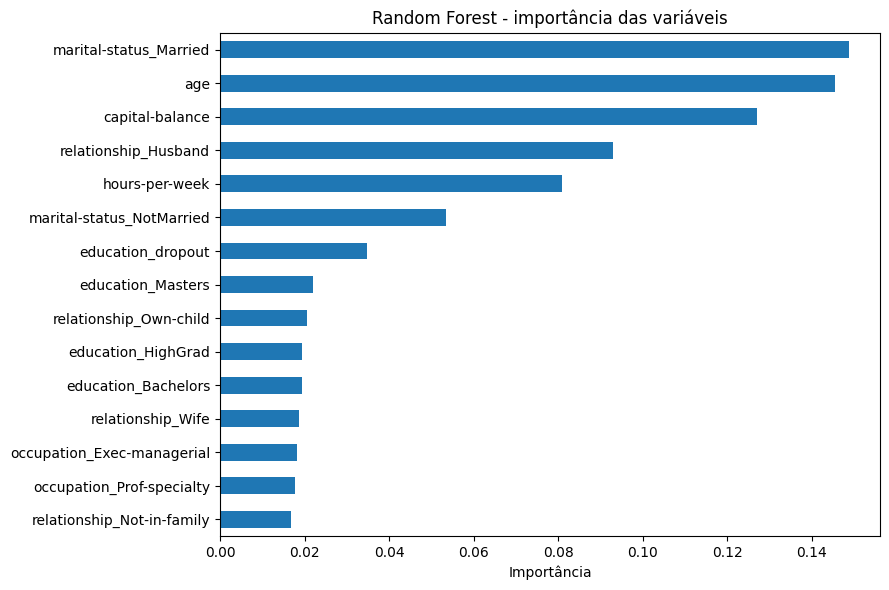

In [35]:
best_pipeline = final_search_rf.best_estimator_
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = best_pipeline.named_steps["rf"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(importance_df)

ax = importance_df.head(15).plot.barh(
    x="feature",
    y="importance",
    figsize=(9, 6),
    legend=False,
)
ax.invert_yaxis()
ax.set_title("Random Forest - importância das variáveis")
ax.set_xlabel("Importância")
ax.set_ylabel("")
plt.tight_layout()

In [36]:
output_dir = Path("random_forest_outputs")
output_dir.mkdir(exist_ok=True)

fold_results.to_csv(output_dir / "fold_metrics_random_forest.csv", index=False)
summary_results.to_csv(output_dir / "summary_metrics_random_forest.csv", index=False)
importance_df.to_csv(output_dir / "feature_importance_random_forest.csv", index=False)

if "all_inner_results" in globals():
    all_inner_results.to_csv(output_dir / "inner_grid_results_random_forest.csv", index=False)
if "oob_results" in globals():
    oob_results.to_csv(output_dir / "oob_grid_random_forest.csv", index=False)
if "comparison_results" in globals():
    comparison_results.to_csv(output_dir / "comparison_cv_oob_random_forest.csv", index=False)

print(f"Arquivos salvos em: {output_dir.resolve()}")

Arquivos salvos em: C:\Users\vinic\Documents\reconhecimento_de_padroes\random_forest_outputs
